In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from torchvision import models
from torchvision import transforms

import random
import shutil

transform = transforms.ToTensor()

In [2]:
# Define the path to the organized images
organized_folder = "data"

# Define the split ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Loop through each class subdirectory
for class_dir in os.listdir(organized_folder):
    class_path = os.path.join(organized_folder, class_dir)
    if os.path.isdir(class_path):
        # Get all image filenames in the class directory
        all_images = os.listdir(class_path)
        
        # Shuffle the image filenames
        random.shuffle(all_images)
        
        # Calculate the number of images for each split
        total_images = len(all_images)
        train_count = int(total_images * train_ratio)
        val_count = int(total_images * val_ratio)
        test_count = total_images - train_count - val_count
        
        # Create subdirectories for train, val, and test
        for split in ['train', 'val', 'test']:
            split_dir = os.path.join(organized_folder, split, class_dir)
            os.makedirs(split_dir, exist_ok=True)
        
        # Move images to the corresponding subdirectories
        for i, image in enumerate(all_images):
            if i < train_count:
                split = 'train'
            elif i < train_count + val_count:
                split = 'val'
            else:
                split = 'test'
            
            shutil.move(os.path.join(class_path, image), os.path.join(organized_folder, split, class_dir, image))

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),             # resize all images
    transforms.RandomHorizontalFlip(),         # randomly flip image horizontally
    transforms.RandomRotation(10),             # rotate image ±10 degrees
    transforms.ColorJitter(brightness=0.2, 
                           contrast=0.2, 
                           saturation=0.2, 
                           hue=0.1),           # randomly change colors
    transforms.ToTensor()                       # convert image to tensor
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [4]:
root = "data"

organized_folder = "data"

train_data = datasets.ImageFolder(os.path.join(organized_folder, 'train'), transform=train_transform)
val_data = datasets.ImageFolder(os.path.join(organized_folder, 'val'), transform=val_test_transform)
test_data = datasets.ImageFolder(os.path.join(organized_folder, 'test'), transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes

print(class_names)
print(f'Training images available: {len(train_data)}')
print(f"Validation images available: {len(val_data)}")
print(f'Testing images available:  {len(test_data)}')

['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']
Training images available: 1588
Validation images available: 197
Testing images available:  201


Labels: [0 1 1 1 2 1 1 3 2 4 4 2 3 4 0 3 3 0 2 3 3 3 2 0 2 3 0 3 1 0 3 3]
Classes: ['Healthy', 'Mild DR', 'Mild DR', 'Mild DR', 'Moderate DR', 'Mild DR', 'Mild DR', 'Proliferate DR', 'Moderate DR', 'Severe DR', 'Severe DR', 'Moderate DR', 'Proliferate DR', 'Severe DR', 'Healthy', 'Proliferate DR', 'Proliferate DR', 'Healthy', 'Moderate DR', 'Proliferate DR', 'Proliferate DR', 'Proliferate DR', 'Moderate DR', 'Healthy', 'Moderate DR', 'Proliferate DR', 'Healthy', 'Proliferate DR', 'Mild DR', 'Healthy', 'Proliferate DR', 'Proliferate DR']


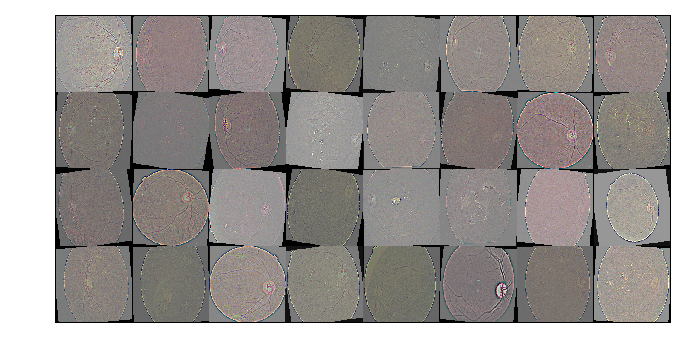

In [5]:
# Get a single batch
for images, labels in train_loader:
    break  # just take the first batch

# Print the labels
print('Labels:', labels.numpy())  # if on GPU: labels.cpu().numpy()
print('Classes:', [class_names[i] for i in labels])

# Make a grid of images
im = make_grid(images, nrow=8)  # display 16 images per row

# Plot the images
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.axis('off')  # hide axes
plt.show()

In [6]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 5, 1)
        self.conv2 = nn.Conv2d(16, 32, 5, 1)
        self.fc1 = nn.Linear(61*61*32, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 5)
        self.dropout = nn.Dropout(p=0.3)


    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 61*61*32)
        X = F.relu(self.fc1(X))
        X = self.dropout(X)
        X = F.relu(self.fc2(X))
        X = self.dropout(X)
        X = self.fc3(X)
        return X


In [7]:
torch.manual_seed(101)
model = ConvolutionalNetwork()
temp = []
for param in model.parameters():
    temp.append(param.numel())
print(sum(temp))



30513509


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [10]:
train_data = datasets.ImageFolder(os.path.join(organized_folder, 'train'), transform=train_transform)
val_data   = datasets.ImageFolder(os.path.join(organized_folder, 'val'), transform=val_test_transform)
test_data  = datasets.ImageFolder(os.path.join(organized_folder, 'test'), transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes
print(class_names)
num_classes = len(train_data.classes)


['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']



Epoch 1/10


C:\Users\Wesam\anaconda3\envs\pytorchenv\lib\site-packages\torchvision\models\_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and may be removed in the future, "
C:\Users\Wesam\anaconda3\envs\pytorchenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 1.3639, Train Acc: 44.77% | Val Loss: 1.4704, Val Acc: 50.25%

Epoch 2/10
Train Loss: 1.2022, Train Acc: 51.45% | Val Loss: 1.3439, Val Acc: 49.24%

Epoch 3/10
Train Loss: 1.1175, Train Acc: 54.47% | Val Loss: 1.1018, Val Acc: 58.38%

Epoch 4/10
Train Loss: 1.0683, Train Acc: 56.05% | Val Loss: 1.0520, Val Acc: 58.38%

Epoch 5/10
Train Loss: 1.0421, Train Acc: 57.62% | Val Loss: 1.0525, Val Acc: 61.42%

Epoch 6/10
Train Loss: 1.0348, Train Acc: 58.82% | Val Loss: 1.1020, Val Acc: 59.90%

Epoch 7/10
Train Loss: 1.0026, Train Acc: 59.07% | Val Loss: 1.0649, Val Acc: 60.91%

Epoch 8/10
Train Loss: 0.9995, Train Acc: 60.39% | Val Loss: 1.0031, Val Acc: 57.87%

Epoch 9/10
Train Loss: 0.9927, Train Acc: 60.64% | Val Loss: 0.9909, Val Acc: 61.42%

Epoch 10/10
Train Loss: 0.9513, Train Acc: 61.52% | Val Loss: 0.9393, Val Acc: 59.39%

Training Time: 381s


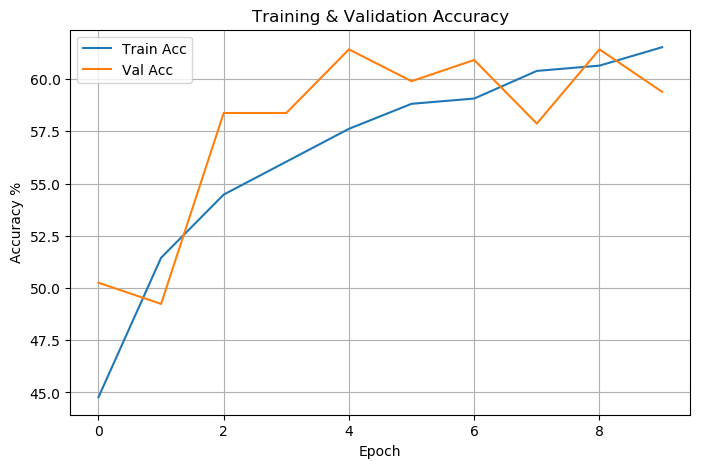

In [11]:
# ✅ Load Pretrained ResNet18 (FREEZE everything except classifier)
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ✅ Training loop
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

epochs = 10
start = time.time()

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # ---- Train ----
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---- Validation ----
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print(f"\nTraining Time: {int(time.time() - start)}s")

# ✅ Plot learning curves
plt.figure(figsize=(8,5))
plt.plot(train_accuracies,label="Train Acc")
plt.plot(val_accuracies,label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# ✅ Unfreeze deeper layers: layer3 & layer4
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

# ✅ Low LR since we are updating pretrained weights
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00005
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.3, patience=2, verbose=True
)

fine_tune_epochs = 12
best_val_acc_ft = 0
early_stop = 0

train_losses_ft, val_losses_ft = [], []
train_accs_ft, val_accs_ft = [], []

print("\n🔧 Starting deeper fine-tuning...")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss_ft = running_loss / len(train_loader)
    train_acc_ft = 100 * correct / total
    train_losses_ft.append(train_loss_ft)
    train_accs_ft.append(train_acc_ft)

    # ✅ Validation
    model.eval()
    val_loss_ft, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_ft += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss_ft /= len(val_loader)
    val_acc_ft = 100 * correct / total
    val_losses_ft.append(val_loss_ft)
    val_accs_ft.append(val_acc_ft)

    scheduler.step(val_loss_ft)

    print(f"Deep FT Epoch {epoch+1}/{fine_tune_epochs} | "
          f"Train Loss: {train_loss_ft:.4f} | Train Acc: {train_acc_ft:.2f}% | "
          f"Val Loss: {val_loss_ft:.4f} | Val Acc: {val_acc_ft:.2f}%")

    # ✅ Early stopping based on val acc
    if val_acc_ft > best_val_acc_ft:
        best_val_acc_ft = val_acc_ft
        torch.save(model.state_dict(), "best_finetuned_model.pth")
        early_stop = 0
    else:
        early_stop += 1
        if early_stop >= 3:
            print("⏹️ Early stopping triggered! No val improvement.")
            break

print("\n✅ Fine-tuning complete!")


🔧 Starting deeper fine-tuning...
Deep FT Epoch 1/12 | Train Loss: 0.9325 | Train Acc: 61.71% | Val Loss: 0.8477 | Val Acc: 62.94%
Deep FT Epoch 2/12 | Train Loss: 0.7956 | Train Acc: 69.33% | Val Loss: 0.8214 | Val Acc: 70.05%
Deep FT Epoch 3/12 | Train Loss: 0.7443 | Train Acc: 71.47% | Val Loss: 0.7915 | Val Acc: 64.47%
Deep FT Epoch 4/12 | Train Loss: 0.6727 | Train Acc: 72.54% | Val Loss: 0.7571 | Val Acc: 70.05%
Deep FT Epoch 5/12 | Train Loss: 0.6268 | Train Acc: 74.87% | Val Loss: 0.7520 | Val Acc: 64.47%
⏹️ Early stopping triggered! No val improvement.

✅ Fine-tuning complete!


Classes: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']

🚀 Starting Phase 1: Classifier Training...

Phase 1: Classifier Training Epoch 1/6 | Train Acc: 37.66% | Val Acc: 51.78% | Time: 29s
Phase 1: Classifier Training Epoch 2/6 | Train Acc: 45.53% | Val Acc: 55.33% | Time: 29s
Phase 1: Classifier Training Epoch 3/6 | Train Acc: 50.69% | Val Acc: 55.84% | Time: 30s
Phase 1: Classifier Training Epoch 4/6 | Train Acc: 50.31% | Val Acc: 61.93% | Time: 30s
Phase 1: Classifier Training Epoch 5/6 | Train Acc: 54.53% | Val Acc: 63.96% | Time: 29s
Phase 1: Classifier Training Epoch 6/6 | Train Acc: 53.34% | Val Acc: 61.42% | Time: 30s

🚀 Starting Phase 2: Deep Fine-Tuning...

Phase 2: Deep Fine-Tuning Epoch 1/10 | Train Acc: 55.60% | Val Acc: 65.48% | Time: 43s
Phase 2: Deep Fine-Tuning Epoch 2/10 | Train Acc: 64.67% | Val Acc: 65.48% | Time: 43s
Phase 2: Deep Fine-Tuning Epoch 3/10 | Train Acc: 65.05% | Val Acc: 68.53% | Time: 44s
Phase 2: Deep Fine-Tuning Epoch 4/10 | T

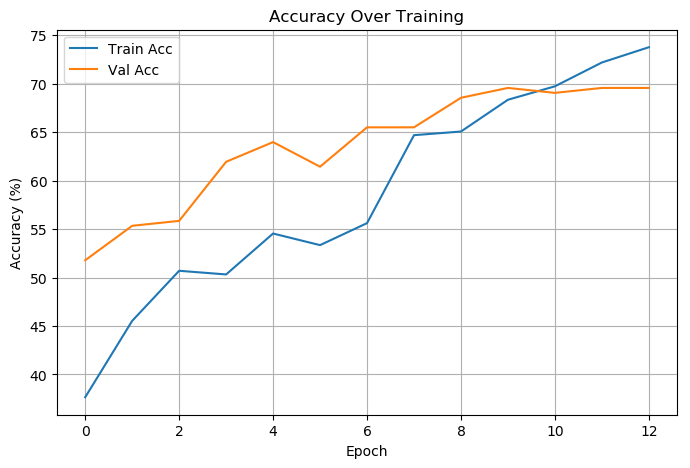


✅ Training Complete & Model Saved!


In [13]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

organized_folder = "data"

# ---------------------------------
# ✅ Transformations (fixed order!)
# ---------------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# ---------------------------------
# ✅ Load Data
# ---------------------------------
train_data = datasets.ImageFolder(os.path.join(organized_folder, 'train'), transform=train_transform)
val_data   = datasets.ImageFolder(os.path.join(organized_folder, 'val'),   transform=val_test_transform)
test_data  = datasets.ImageFolder(os.path.join(organized_folder, 'test'),  transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

# ---------------------------------
# ✅ Load ResNet18 + Freeze backbone
# ---------------------------------
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False  # freeze all

model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, num_classes)
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)

# ---------------------------------
# ✅ Training Function with Early Stopping
# ---------------------------------
def train_phase(model, optimizer, epochs, phase_name):
    train_accs, val_accs = [], []
    best_val = 0
    patience, patience_limit = 0, 3

    print(f"\n🚀 Starting {phase_name}...\n")

    for epoch in range(epochs):
        start = time.time()

        # Train
        model.train()
        correct, total, run_loss = 0, 0, 0
        for x, y in train_loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            run_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_acc = correct / total * 100
        train_accs.append(train_acc)

        # Validate
        model.eval()
        correct, total, val_loss = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_acc = correct / total * 100
        val_accs.append(val_acc)

        elapsed = int(time.time() - start)
        print(f"{phase_name} Epoch {epoch+1}/{epochs} "
              f"| Train Acc: {train_acc:.2f}% "
              f"| Val Acc: {val_acc:.2f}% "
              f"| Time: {elapsed}s")

        # Early stopping
        if val_acc > best_val:
            best_val = val_acc
            patience = 0
        else:
            patience += 1
            if patience >= patience_limit:
                print("⏹️ Early stopping triggered!\n")
                break

    return train_accs, val_accs

# ---------------------------------
# ✅ PHASE 1: Only train classifier
# ---------------------------------
train_acc1, val_acc1 = train_phase(model, optimizer, 6, "Phase 1: Classifier Training")

# ---------------------------------
# ✅ PHASE 2: Unfreeze deeper layers
# ---------------------------------
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)

train_acc2, val_acc2 = train_phase(model, optimizer, 10, "Phase 2: Deep Fine-Tuning")

# ---------------------------------
# ✅ Plot learning curves
# ---------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_acc1 + train_acc2, label="Train Acc")
plt.plot(val_acc1 + val_acc2, label="Val Acc")
plt.title("Accuracy Over Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------
# ✅ Save Model
# ---------------------------------
torch.save(model.state_dict(), "final_finetuned_resnet18.pth")
print("\n✅ Training Complete & Model Saved!")


In [14]:
class_names = train_data.classes
print("Classes:", class_names)

Classes: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']


C:\Users\Wesam\anaconda3\envs\pytorchenv\lib\site-packages\sklearn\utils\validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'



✅ Test Accuracy: 67.66%

📊 Classification Report:
                precision    recall  f1-score   support

       Healthy       0.93      0.94      0.93        53
       Mild DR       0.70      0.43      0.53        37
   Moderate DR       0.57      0.90      0.70        61
Proliferate DR       0.53      0.28      0.36        29
     Severe DR       0.58      0.33      0.42        21

     micro avg       0.68      0.68      0.68       201
     macro avg       0.66      0.58      0.59       201
  weighted avg       0.68      0.68      0.65       201



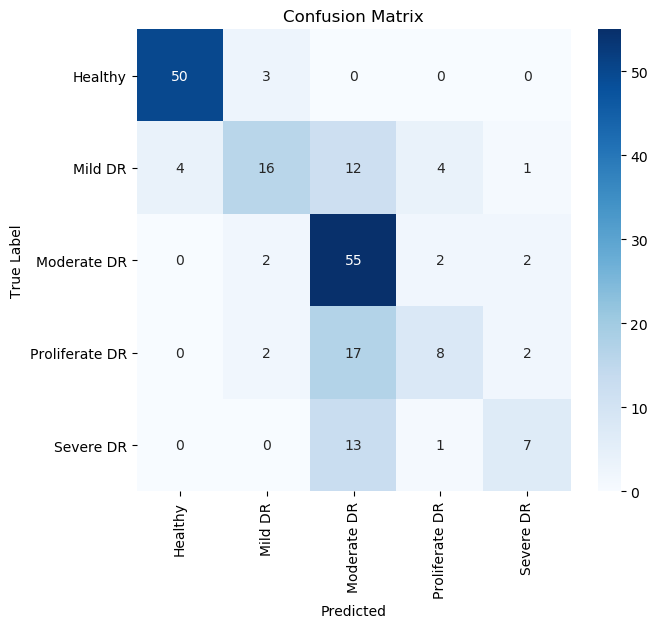

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ✅ Load best model weights (saved during training)
model.load_state_dict(torch.load("final_finetuned_resnet18.pth"))
model.eval()

correct, total = 0, 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ Test Accuracy
test_accuracy = 100 * correct / total
print(f"\n✅ Test Accuracy: {test_accuracy:.2f}%")

# ✅ Classification Report
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ✅ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()